## 评估文本生成模型
### 使用GPT生成文本

In [1]:
import sys
import os
# 获取当前文件的目录
root_dir = os.path.dirname(os.path.abspath("."))  # "." 就是当前 notebook 的运行目录
# 把根目录加入 sys.path
sys.path.append(root_dir)
# print(root_dir)
from ch04.GPTModel import GPTModel
import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 总词汇表大小，即一共有多少个单词
    "context_length": 256, # 上下文窗口长度，即将vocab_size进行切分后，每组的大小
    "emb_dim": 768,         # 词元 embeding 维度，将单个词嵌入后的维度大小
    "n_heads": 12,          # 注意力头数量
    "n_layers": 12,         # 网络层数
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features

In [2]:
import tiktoken
from ch04.GPTModel import generate_text_simple
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # 添加batch维度
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) 
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # 移除batch维度
    flat = token_ids.squeeze(0) 
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_length=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 计算文本生成损失

![textGenPipeline](imgs/textGenPipeline.png)

上图展示了从输入文本到大语言模型生成文本的整体流程。对于左侧显示的3个输入词元中的每一个，计算包含词汇表中每个词元对应概率分数的向量。每个向量中最高概率分数的索引位置表示最有可能的下一个词元ID。这些与最高概率分数相关联的词元ID会被选中并映射回表示模型生成的文本

接下来我们先模拟一下损失计算过程

In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

inputs是我们输入给模型的示例词元id，targets是我们希望模型生成的词元ID，其中targets是对输入数据的复制，但向前移动了一个位置

现在，将这些输入提供给模型，为包含3个词元的两个输入示例计算logits向量。然后，应用softmax函数将这些logits转换为概率分数

In [4]:
with torch.no_grad():
    logits = model(inputs)
print(logits.shape)
probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])
torch.Size([2, 3, 50257])


第一个数值2对应于输入中的两个示例（行）​，也称为“批次大小”​。第二个数值3对应于每个输入（行）中的词元数量。最后一个数值50257对应于嵌入维度，由词汇表大小确定。通过softmax函数将logits转换为概率后，generate_text_simple函数会将结果概率分数转换回文本（参见图5-4的第3～5步）​。可以通过将argmax函数应用于概率分数来完成第3步和第4步，从而获得相应的词元ID

In [5]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


最后，将词元ID转换回文本

In [6]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


模型生成的随机文本与目标文本不同的原因是它尚未经过训练。现在，我们希望通过损失指标来量化评估模型生成的文本的性能。这不仅有助于衡量生成的文本的质量，同时也是实现训练函数的一个构建块，我们将使用它来更新模型的权重，从而改善生成的文本。

文本评估过程的一部分是衡量生成词元与正确预测（目标）之间的偏差程度。我们稍后实现的训练函数将使用这些信息来调整模型权重，以生成更接近（或理想情况下更匹配）目标文本的文本

模型训练的目标是增大与正确目标词元ID对应的索引位置的softmax概率。这个softmax概率也将用于我们接下来要实现的评估指标中，以量化评估模型生成的输出：正确位置的概率越高，效果越好

In [7]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


上述代码输出了模型输出的目标词元对应的初始softmax概率分数

这只是模型的第一次迭代输出，我们最终的目标是想让这些概率值等无限接近于1，为此我们需要构造一个损失函数来进行最优迭代，这个最优迭代的过程就是训练的过程，在神经网络中我们称这一过程为反向传播

反向传播需要一个损失函数，它会计算模型的预测输出（在这里是与目标词元ID对应的概率）与实际期望输出之间的差异。这个损失函数衡量的是模型的预测与目标值之间的偏差。

接下来，我们将计算两个示例批次的概率分数的损失，即target_probas_1和target_probas_2。

In [8]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


在数学优化中，使用概率分数的对数比直接处理分数更容易操作

接下来，我们通过计算平均值将这些对数概率组合成一个单一分数

In [9]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


我们的目标是通过在训练过程中更新模型的权重，使平均对数概率尽可能接近0。然而，在深度学习中，通常的做法不是将平均对数概率升至0，而是将负平均对数概率降至0。负平均对数概率就是平均对数概率乘以-1

In [10]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


在深度学习中，将-10.7940这个负值转换为10.7940的术语称为交叉熵损失。PyTorch在这里派上了用场，因为它有一个内置的cross_entropy函数

交叉熵损失是一种常用的度量方式，用于衡量两个概率分布之间的差异

In [11]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)


"""
F.cross_entropy 要求输入是 (N, C) 和 (N,) 的形状，其中：
N = 样本总数（这里是 2×3=6 个独立的预测位置）
C = 类别数（50257 个词）
把 (2, 3) 的序列维度展平，本质上是把每个 token 位置的预测都当作一个独立的分类问题。
"""
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])
Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


targets是我们希望大语言模型生成的词元ID，而logits是在进入softmax函数以获取概率分数之前的未经缩放的模型输出。

先前，我们应用softmax函数，选择了与目标ID对应的概率分数，并计算了负对数概率的平均值。PyTorch的cross_entropy函数将为我们处理所有这些步骤

In [12]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


### 计算训练集和验证集的损失

本节的主要工作是准备用于训练大语言模型的训练数据集和验证数据集，并计算训练集和验证集的交叉熵

In [13]:
with open("the-verdict.txt","r") as f:
    text_data=f.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [14]:
from ch02.DateSet import create_dataloader_v1

# 将文本的90%内容作为训练集，剩余的10%内容构建成验证集
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# 测试检查数据集是否创建成功
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


如上输出，我们有9个训练集批次，其中每个批次包含两个样本，每个样本包含256个词元。

由于我们仅将10%的数据用于验证，因此只有一个包含两个输入示例的验证批次。正如预期的那样，输入数据(x)和目标数据(y)具有相同的形状（批次大小×每个批次中的词元数）​，因为targets是将输入向后移动一个位置得到的

接下来，我们实现一个工具函数，用于计算通过训练集加载器和验证集加载器返回的给定批次的交叉熵损失

In [15]:
# 计算单批次损失
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [16]:
# 计算所有批次的损失
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

calc_loss_loader函数会遍历给定数据加载器中的所有批次，将损失累积在total_loss变量中，然后计算所有批次的损失的平均值。或者，可以通过num_batches指定较小的批次数，以加快模型训练期间的评估速度

In [17]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")

model.to(device) 

torch.manual_seed(123) 

with torch.no_grad(): 
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cpu device.


Training loss: 10.98758347829183
Validation loss: 10.98110580444336


由于模型尚未经过训练，因此损失值相对较高。相比之下，如果模型学会按照训练集和验证集中词元的出现顺序生成下一个词元，那么损失将接近于0

现在我们有了一种衡量生成文本质量的方法，我们将训练大语言模型以减少这种损失，使其在生成文本方面变得更好

## 训练大语言模型

In [18]:
# 模型训练
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 初始化列表，记录损失
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # epoch迭代
    for epoch in range(num_epochs):
        model.train()  
        
        for input_batch, target_batch in train_loader:
            # 重置上一个批次迭代中的损失梯度
            optimizer.zero_grad() 
            # 计算损失
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            # 计算损失梯度
            loss.backward()
            # 使用损失梯度更新模型权重 
            optimizer.step() 
            tokens_seen += input_batch.numel()
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 每轮之后打印一个文本样本
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_length=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

evaluate_model函数会在每次模型更新后打印训练集和验证集的损失，以便我们可以评估训练是否改善了模型性能。具体而言，evaluate_model函数在计算训练集和验证集的损失时会确保模型处于评估模式，同时会禁用梯度跟踪和Dropout

generate_and_print_sample函数可以用来跟踪模型在训练过程中是否有所改进。具体而言，generate_and_print_sample函数以文本片段(start_context)作为输入，先将其转换为词元ID，然后将其提供给大语言模型，最后使用我们之前使用的generate_text_simple函数生成一个文本样本

Adam优化器是训练深度神经网络的一种常见选择。然而，我们的训练循环中选择了AdamW优化器。AdamW是Adam的一个变体，它改进了权重衰减方法，旨在通过对较大的权重进行惩罚来最小化模型复杂性并防止过拟合。

这种调整使得AdamW能够实现更有效的正则化和更好的泛化能力。因此，在大语言模型的训练中经常使用AdamW。我们通过使用之前定义的AdamW优化器和train_model_simple函数，对一个GPTModel实例进行10轮的训练，来看看这一切是如何运作的

In [19]:
import time
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# 定义优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
# optimizer = torch.optim.SGD(model.parameters(), lr=5e-3)

# 设置迭代轮数
num_epochs = 10
# 开始训练
start_time=time.time()
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

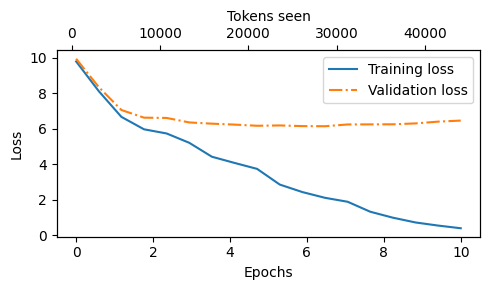

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)